In [1]:
import os
import sys
import mlflow
import torch
import numpy as np
from tqdm import tqdm

PROJECT_PATH = os.getcwd()
sys.path.append(PROJECT_PATH)

from src.FISTANet.trainer import FISTANetTrainer
from src.FISTANet.loader import DataSplit

In [2]:
# data paths and configuration
DATA_DIR = os.path.join(PROJECT_PATH, 'data')
DATA_FILE_GEN = 'dataset_master_10000.pkl'
DATA_FILE_SIGS = 'ECG-QDB_cat-1.npy'
DATA_FILE_NOISE = 'MIT-BIH/bw'
DATA_FILE_DICT = 'dictionary_BW_real_data.npy'
DATA_SIZE = 10000
TVT_SPLIT = {
    'train': 80,
    'valid': 10,
    'test': 10
}

# FISTA-Net model configuration
FNET_LAYER_NO = 4
FNET_FEATURE_NO = 16

# training parameters
LAMBDA_LSPA = 1
LAMBDA_LFSYM = 1e-3
LAMBDA_LFSPA = 1e-2
BATCH_SIZE = 1000
LEARNING_RATE = 1e-3

# seed for random generators
RANDOM_SEED = 42

# local MLflow-format checkpoint (see models/FISTA-Net_ep20000/MLmodel)
LOAD_MODEL_DIR = os.path.join(PROJECT_PATH, 'models', 'FISTA-Net_ep20000')

In [3]:
# seed random generators to ensure deterministic inference
generator = torch.Generator()
generator.manual_seed(RANDOM_SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

trn_ldr, val_ldr, tst_ldr = DataSplit(
    DATA_DIR, DATA_FILE_GEN, DATA_FILE_SIGS, DATA_FILE_NOISE,
    TVT_SPLIT, BATCH_SIZE, generator=generator
)
Psi = np.load(os.path.join(DATA_DIR, DATA_FILE_DICT))

loaded_model = mlflow.pytorch.load_model(LOAD_MODEL_DIR).to(device)

params = {
    'device': device,
    'fnet_layer_no': FNET_LAYER_NO,
    'fnet_feature_no': FNET_FEATURE_NO,
    'lambda_Lspa': LAMBDA_LSPA,
    'lambda_LFsym': LAMBDA_LFSYM,
    'lambda_LFspa': LAMBDA_LFSPA,
    'load_model_run': None,
    'load_model_epoch': None,
    'batch_size': BATCH_SIZE,
    'lr': LEARNING_RATE,
}
trainer = FISTANetTrainer(loaded_model, Psi, params)

# Same pattern as model_inference.ipynb: list of [Yhat, Xhat] per batch, then stack sparse codes.
for y_noisy, y_target in tqdm(tst_ldr, desc='FISTA-Net infer'):
    x_fistanet = trainer.infer(y_noisy)[1].squeeze()

# x_fistanet = torch.stack([l[1] for l in res], dim=0).flatten(0, 1).squeeze()

FISTA-Net infer: 100%|██████████| 1/1 [00:00<00:00,  1.41it/s]


In [4]:
import matplotlib.pyplot as plt

def plot_single_signal(signal, color, figname, xlim=[0, 2500], ylim=[-0.5, 2.8], figsize=(13, 4), linewidth=3):
    fig = plt.figure(figsize=figsize, dpi=300)
    plt.plot(signal, color=color, linewidth=linewidth)
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.xticks([])
    plt.yticks([])

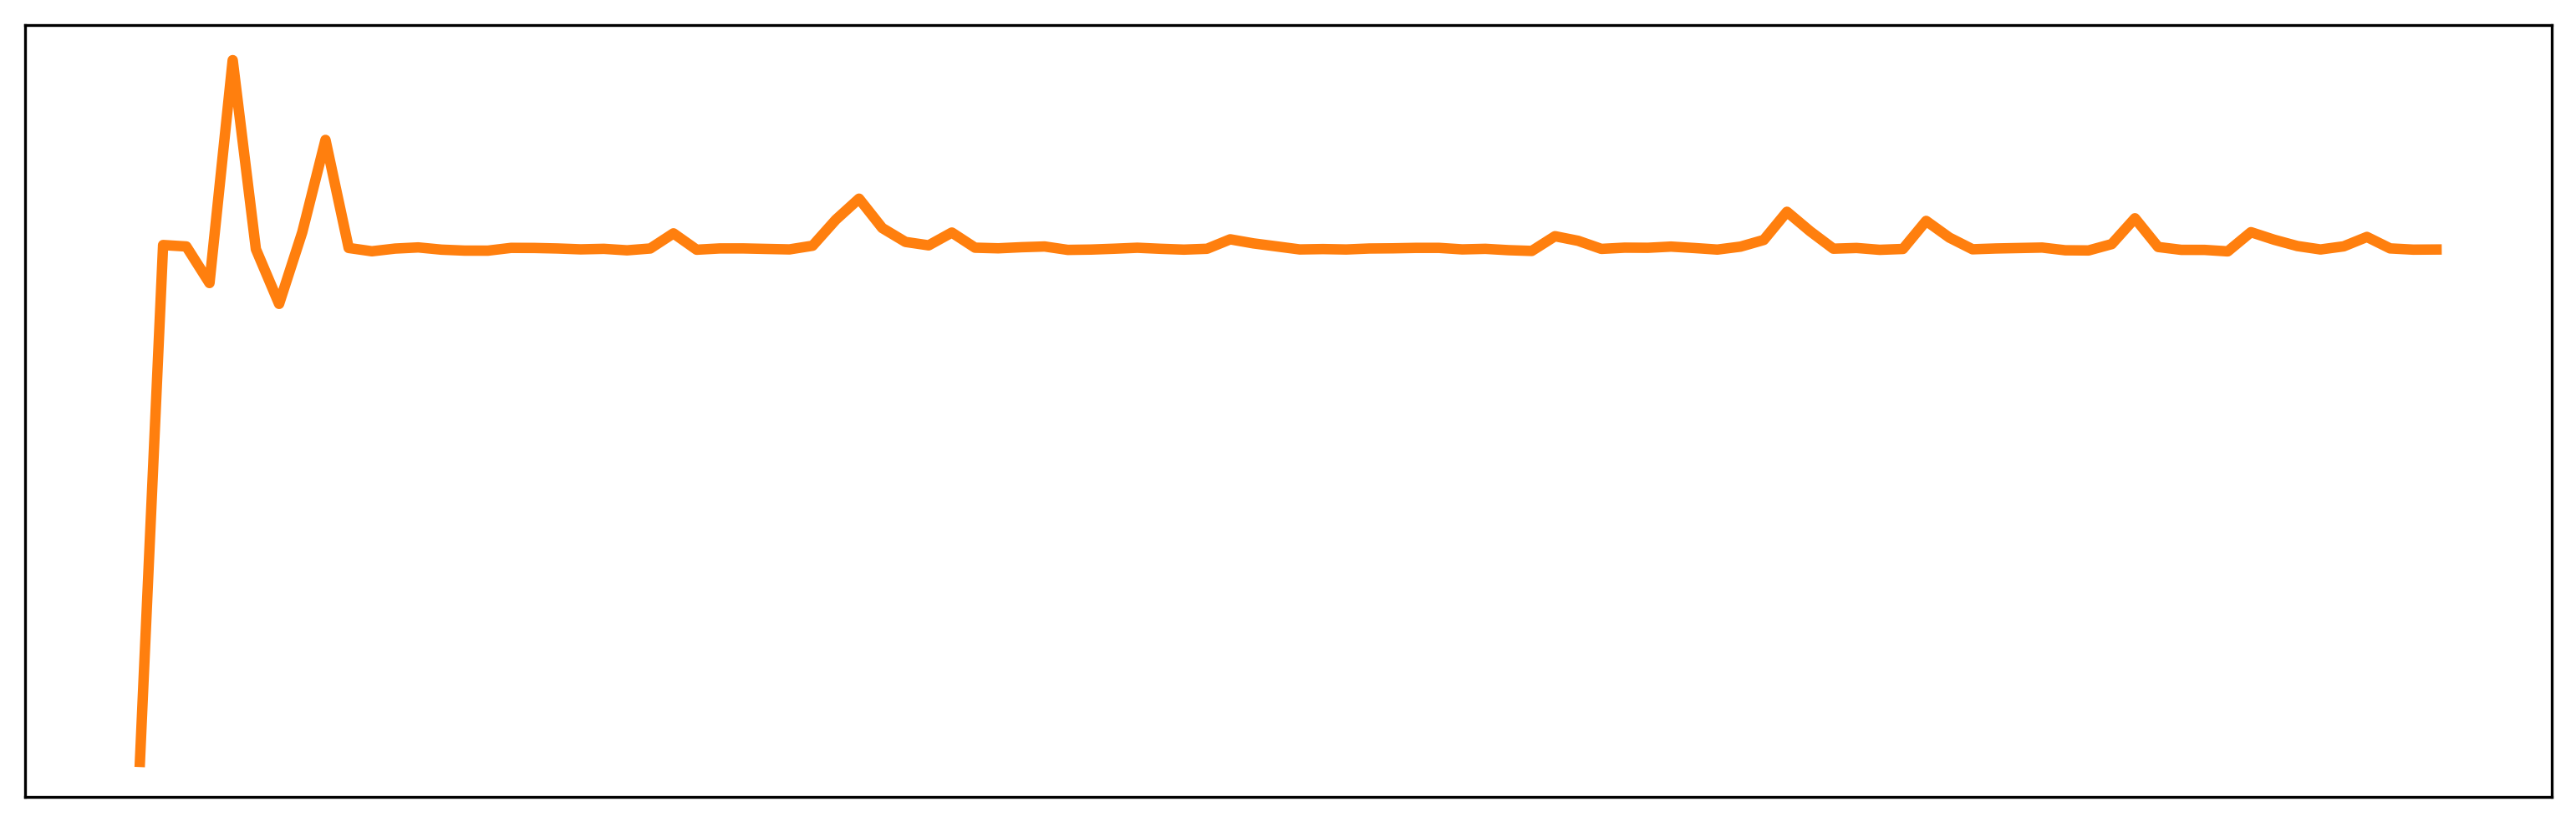

In [5]:
plot_single_signal(x_fistanet[11].cpu().squeeze(), 'tab:orange', 'x_fistanet', None, None)

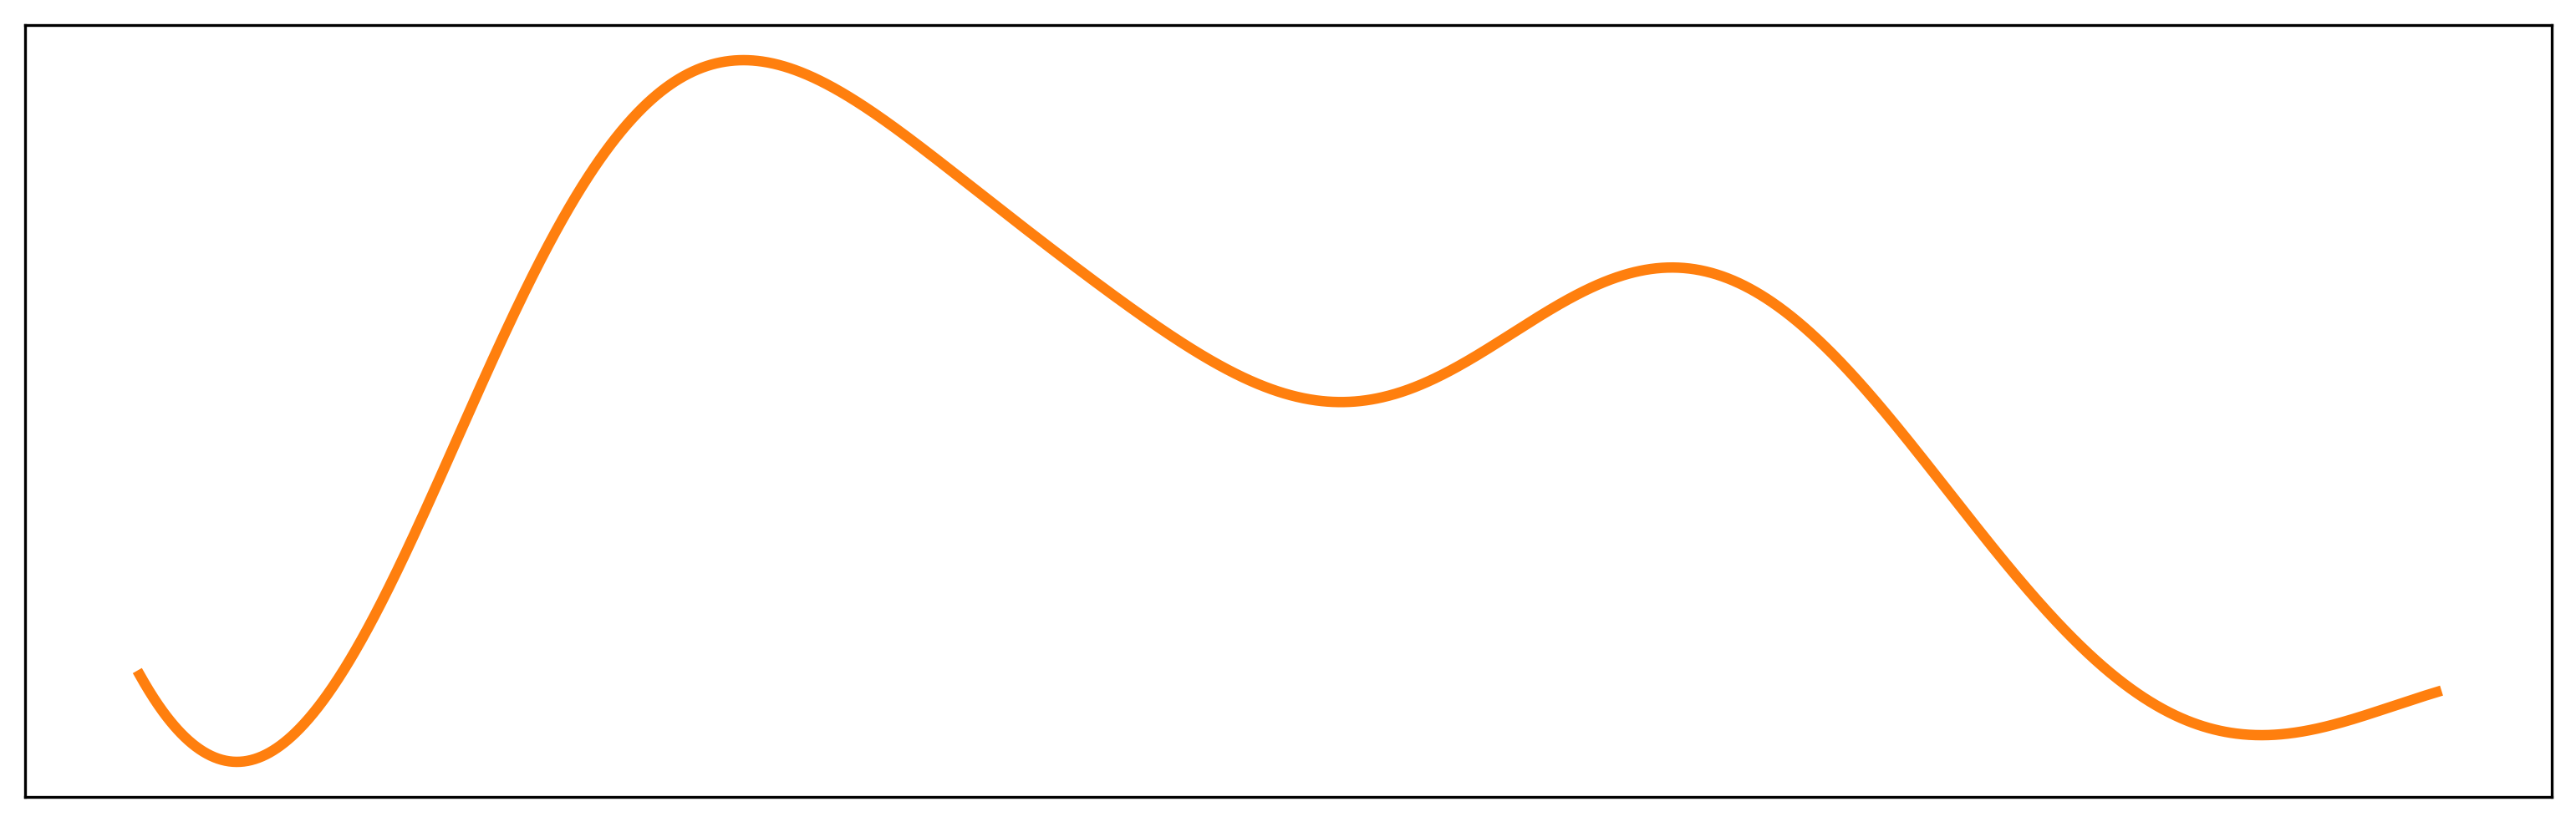

In [6]:
plot_single_signal((x_fistanet[11].unsqueeze(0).cpu() @ Psi.T).squeeze(), 'tab:orange', 'x_fistanet', None, None)

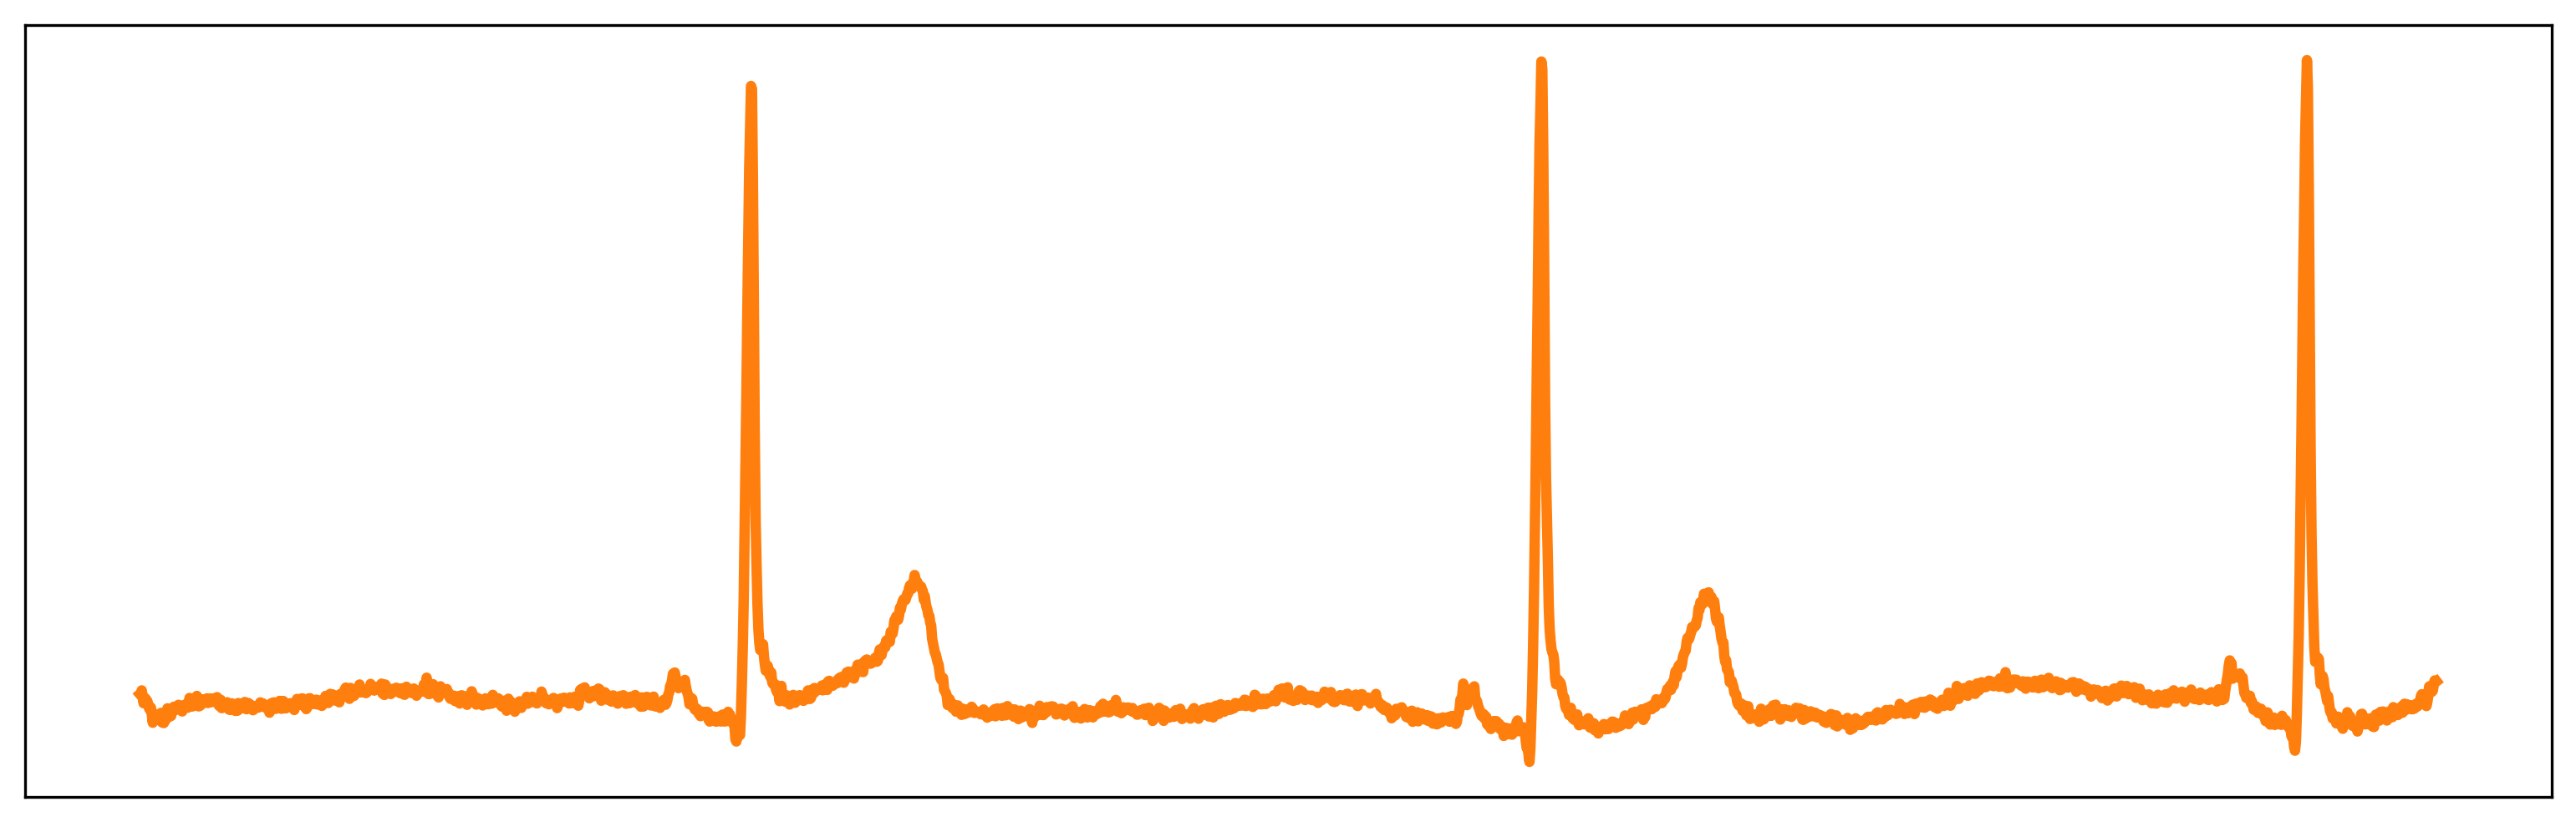

In [7]:
plot_single_signal(y_noisy[11] - (x_fistanet[11].unsqueeze(0).cpu() @ Psi.T).squeeze(), 'tab:orange', 'x_fistanet', None, None)